In [107]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import inspect

sp.init_printing("mathjax")

# Solving for angular acceleration

In [108]:
r_inner, rcm, m, I, g, t = sp.symbols("r_\\text{inner} r_\\text{cm} m I g t")
muv, muq, muc = sp.symbols("\\mu_v \\mu_q \\mu_c")

theta = sp.Function("\\theta")(t)
theta_d = sp.diff(theta, t)

In [109]:
T = sp.Rational(1, 2) * I * theta_d**2
V = -m*g*rcm*sp.cos(theta)
L = T - V

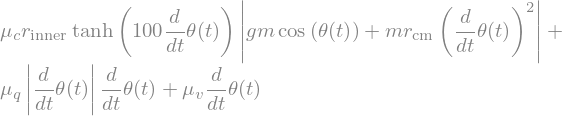

In [110]:
normal_force = sp.Abs(-m*rcm*theta_d*theta_d - m*g*sp.cos(theta))
friction_forces = muv*theta_d + muq*sp.Abs(theta_d)*theta_d + muc*normal_force*r_inner*sp.tanh(theta_d * 100)

friction_forces

In [111]:
eq_motion = sp.Equality(
    sp.diff(
        sp.diff(L, theta_d),
        t
    )
    -
    sp.diff(L, theta),
    friction_forces
)

acc = sp.solve(eq_motion, sp.diff(theta_d, t))[0]
acc_func = sp.lambdify((I, rcm, m, g, theta, theta_d, r_inner, muv, muq, muc), acc)

inspect.getsource(acc_func)

'def _lambdifygenerated(I, Dummy_363, m, g, _Dummy_361, _Dummy_360, Dummy_362, Dummy_364, Dummy_365, Dummy_366):\n    return (_Dummy_360*Dummy_364 + _Dummy_360*Dummy_365*abs(_Dummy_360) + Dummy_362*Dummy_366*tanh(100*_Dummy_360)*abs(m*(_Dummy_360**2*Dummy_363 + g*cos(_Dummy_361))) - Dummy_363*g*m*sin(_Dummy_361))/I\n'

# RK4 Simulation

In [112]:
rcm_sim = 10e-2
g_sim = 9.81
I_sim = 1/3 * (2*rcm_sim)**2
m_sim = 200e-3
r_inner_sim = 8e-3
muv_sim = -0.001
muq_sim = -0.0001
muc_sim = -0.01

y = np.array([np.pi - 0.1, 0.1])

def f(y, t):
    return np.array([
        y[1],
        acc_func(I_sim, rcm_sim, m_sim, g_sim, y[0], y[1], r_inner_sim, muv_sim, muq_sim, muc_sim)
    ])

h = 0.01
t = 0
sim_time = 10

I_sim

In [113]:
past_positions = np.array([])
first = True

for i in range(int(sim_time/h)):
    k1 = h*f(y, t)
    k2 = h*f(y + k1/2, t + h/2)
    k3 = h*f(y + k2/2, t + h/2)
    k4 = h*f(y + k3, t + h)

    y = y + k1/6 + k2/3 + k3/3 + k4/6

    if (first):
        past_positions = np.array([y])
        first = False
    else:
        past_positions = np.vstack([past_positions, y])


Getting the position of the end of the arm. Note: I'm now assuming the arm is a solid bar.

In [114]:
# getting the simulated angles out
theta_sim = past_positions[:, 0]

data_rate = 30 #the rate at which (simulated) data is recorded
indices_to_keep = np.linspace(0, len(theta_sim)-1, sim_time*data_rate, dtype=int)
theta_sim_data = theta_sim[indices_to_keep]

# simulating the position measurements we would get, including uncertainties
standard_error = 0
x_sim_err = np.random.normal(0, standard_error, len(theta_sim_data))
y_sim_err = np.random.normal(0, standard_error, len(theta_sim_data))

x_sim = 2*rcm_sim*np.sin(theta_sim_data) + x_sim_err
y_sim = -2*rcm_sim*np.cos(theta_sim_data) + y_sim_err

print("initial condition recorded: " + str(past_positions[0, :]))

initial condition recorded: [3.04251849 0.08519189]


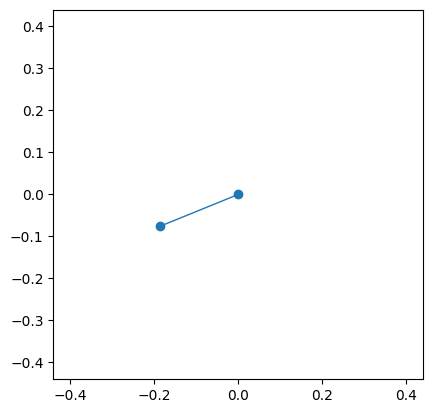

In [119]:
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.set_xlim(-2.2*2*rcm_sim, 2.2*2*rcm_sim)
ax.set_ylim(-2.2*2*rcm_sim, 2.2*2*rcm_sim)

line, = ax.plot([], [], "o-", lw=1)

def init():
    line.set_data([], [])
    return line,

def update(i):
    this_x = [0, x_sim[i]]
    this_y = [0, y_sim[i]]

    line.set_data(this_x, this_y)
    return line,

ani = FuncAnimation(fig, update, frames=len(x_sim), init_func=init, blit=True, interval=data_rate)

ani.save("test_single.mp4")

In [116]:
data = np.vstack(
    (
        np.arange(0, sim_time, 1/data_rate),
        x_sim,
        y_sim,
        np.full(len(x_sim), standard_error),
        np.full(len(x_sim), standard_error)
    )
).transpose()

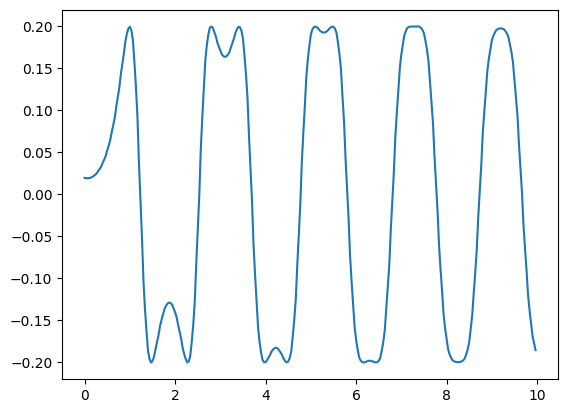

In [117]:
plt.plot(data[:, 0], data[:, 1])

In [118]:
data

array([[ 0.        ,  0.01978243,  0.19901923,  0.        ,  0.        ],
       [ 0.03333333,  0.01940466,  0.19905642,  0.        ,  0.        ],
       [ 0.06666667,  0.0192855 ,  0.199068  ,  0.        ,  0.        ],
       ...,
       [ 9.9       , -0.16853893, -0.10767837,  0.        ,  0.        ],
       [ 9.93333333, -0.1771701 , -0.09279416,  0.        ,  0.        ],
       [ 9.96666667, -0.18525459, -0.07537066,  0.        ,  0.        ]],
      shape=(300, 5))